<a href="https://colab.research.google.com/github/TaranpreetSinghBhatia/ai-mlops-journey/blob/main/phase1_ml_foundations/01_intro_to_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 1: My First ML Model
**Goal:** Understand what ML is by training a real classifier.
**Dataset:** Iris flowers (classic beginner dataset)
**Model:** Decision Tree

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

print("✅ All libraries imported!")

✅ All libraries imported!


In [8]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species_name'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (150, 6)

First 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


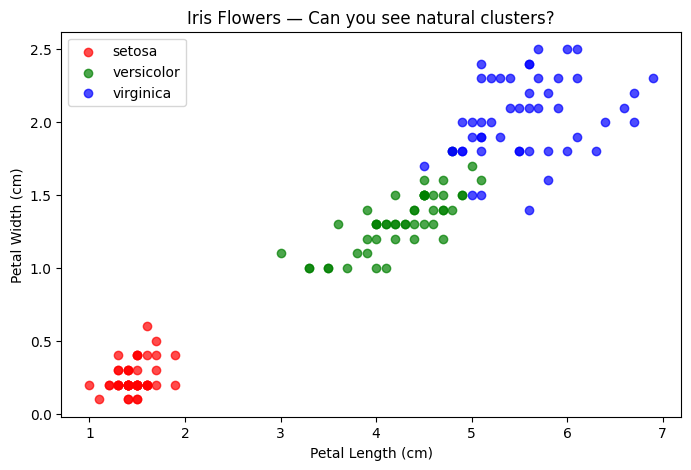

In [9]:
colors = ['red', 'green', 'blue']
species_names = ['setosa', 'versicolor', 'virginica']

plt.figure(figsize=(8, 5))
for i, name in enumerate(species_names):
    subset = df[df['species'] == i]
    plt.scatter(subset['petal length (cm)'],
                subset['petal width (cm)'],
                label=name, color=colors[i], alpha=0.7)

plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Iris Flowers — Can you see natural clusters?')
plt.legend()
plt.show()

In [10]:
X = df[['petal length (cm)', 'petal width (cm)']]
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

print(f"✅ Model trained on {len(X_train)} samples")
print(f"📊 Testing on {len(X_test)} samples")

✅ Model trained on 120 samples
📊 Testing on 30 samples


In [11]:
y_pred = model.predict(X_test)

print(f"🎯 Accuracy: {accuracy_score(y_test, y_pred) * 100:.1f}%\n")
print("Detailed Report:")
print(classification_report(y_test, y_pred, target_names=species_names))

🎯 Accuracy: 100.0%

Detailed Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



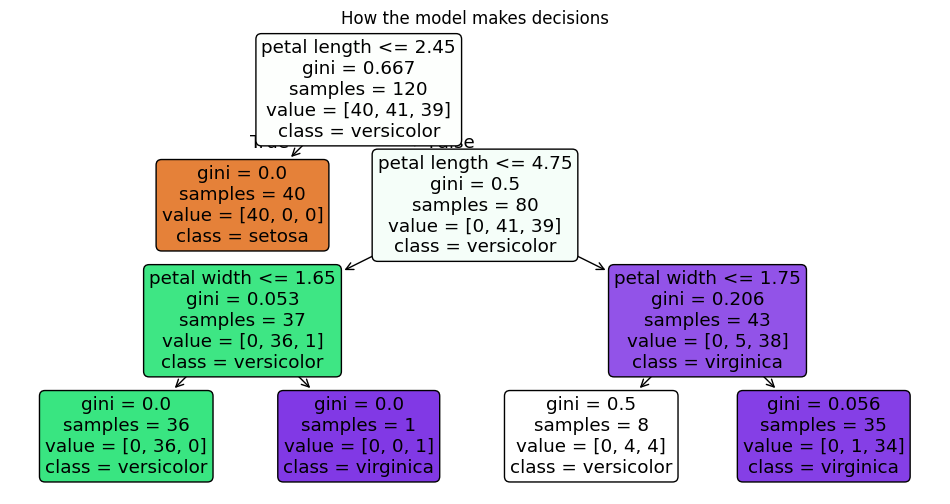

In [12]:
plt.figure(figsize=(12, 6))
plot_tree(model,
          feature_names=['petal length', 'petal width'],
          class_names=species_names,
          filled=True, rounded=True)
plt.title("How the model makes decisions")
plt.show()

In [14]:
new_flower = pd.DataFrame([[4.5, 1.5]], columns=['petal length (cm)', 'petal width (cm)'])
prediction = model.predict(new_flower)
species_map = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}

print(f"🌸 A flower with petal length=4.5cm, width=1.5cm is predicted to be:")
print(f"   👉 {species_map[prediction[0]].upper()}")

🌸 A flower with petal length=4.5cm, width=1.5cm is predicted to be:
   👉 VERSICOLOR
